# Model results

How well the model predicts, and where it fails.

Every number is computed in `src/results.py` and imported here, so this notebook only
draws.

In [3]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src import results as R

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

df = R.load()
f = R.fit_all(df)
print(f"train {len(f.X_train)} rows | test {len(f.X_test)} rows\n")
R.headline(f)

train 3836 rows | test 959 rows



,model,typical error,average error,R2
0,baseline (median),"$41,829","$60,945",-0.044
1,ridge,"$18,922","$36,612",0.605


The baseline predicts the training median for everyone. It is the reference point rather
than a competitor: without it, an error of roughly $18,000 means nothing.

The model roughly halves the typical error, to about 25% of a median salary. A prediction of
$80,000 usually means the truth is between $60,000 and $100,000.

## Predicted against actual

Each point is one respondent from the held-out test set. The diagonal is a perfect
prediction, so vertical distance from it is the error. Both axes are logarithmic because
salaries span four orders of magnitude.

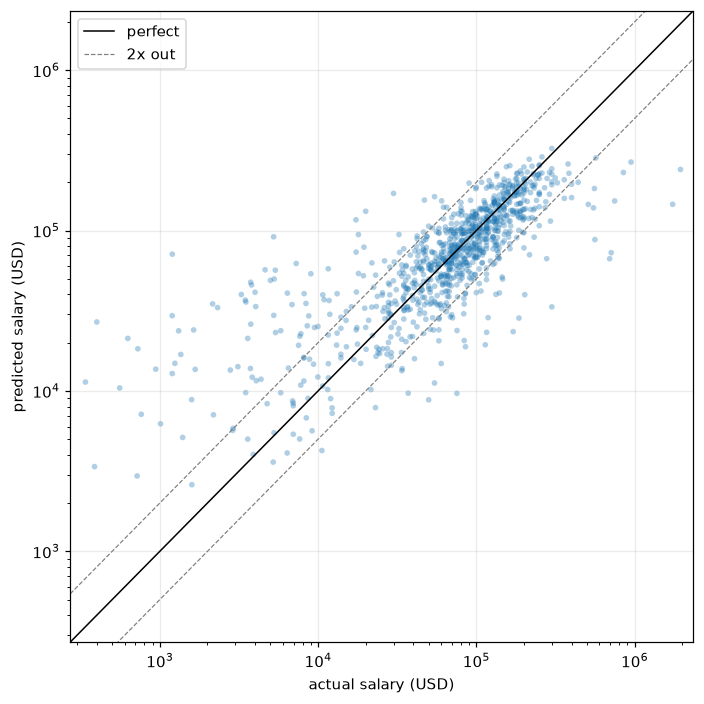

within a factor of 2 of the truth: 82% of predictions


In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(f.y_test, f.pred, s=14, alpha=0.35, edgecolor="none")
lims = [f.y_test.min() * 0.8, f.y_test.max() * 1.2]
ax.plot(lims, lims, lw=1, color="black", label="perfect")
ax.plot(lims, [v * 2 for v in lims], lw=0.8, ls="--", color="grey", label="2x out")
ax.plot(lims, [v / 2 for v in lims], lw=0.8, ls="--", color="grey")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("actual salary (USD)"); ax.set_ylabel("predicted salary (USD)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

s = R.error_summary(f)
print(f"within a factor of 2 of the truth: {s['within a factor of 2']*100:.0f}% of predictions")

Tight through the middle, flaring at both ends.

The flattening on the left is the model refusing to predict very low salaries. It has
learned almost nobody earns $500, so when it meets someone who reportedly does it guesses
far too high. Those are the rows the cleaning could not resolve.

## The error

In [5]:
for k in ["median error", "mean error", "90th percentile", "worst single row"]:
    print(f"{k:<18} ${s[k]:>10,.0f}")

median error       $    18,922
mean error         $    36,612
90th percentile    $    67,697
worst single row   $ 1,709,486


Most predictions are close and a few are very wrong, which is why the mean and median
disagree so much. Quoting only the mean would overstate the error for a typical person, and
quoting only the median would hide that the model fails badly on a minority.

## What the coefficients say

alpha chosen by cross-validation: 14.4
country weight: 0.901   [1.0 would mean adopting each country's own average unchanged]


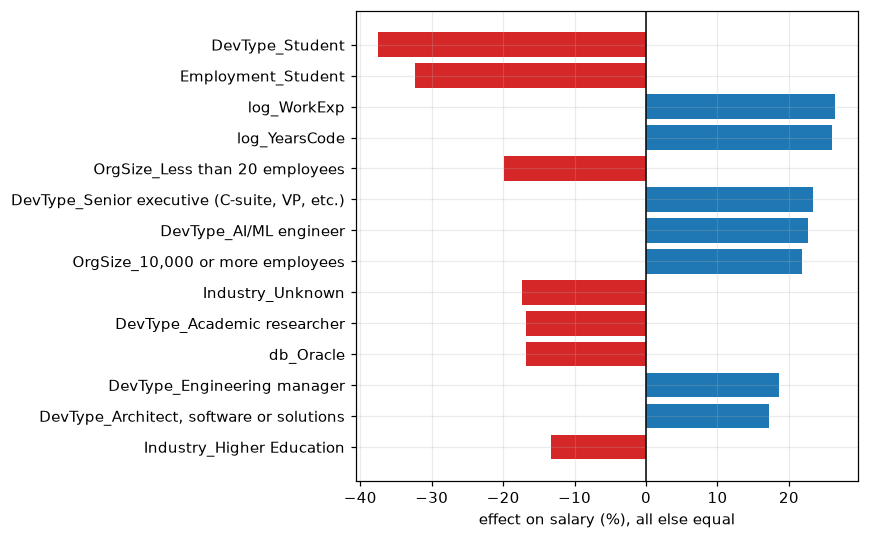

In [6]:
table, alpha, country_weight = R.coefficients(f)
print(f"alpha chosen by cross-validation: {alpha:.1f}")
print(f"country weight: {country_weight:.3f}   "
      "[1.0 would mean adopting each country's own average unchanged]")

top = table.head(14)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.feature, top["effect_%"],
        color=["tab:red" if v < 0 else "tab:blue" for v in top["effect_%"]])
ax.invert_yaxis(); ax.axvline(0, color="black", lw=1)
ax.set_xlabel("effect on salary (%), all else equal")
plt.tight_layout(); plt.show()

## Is it overfitting?

Refit the same model on every row instead of 80% of them, then score it on those same rows.
It has now seen every answer it is being tested on. A model that memorises should improve a
lot.

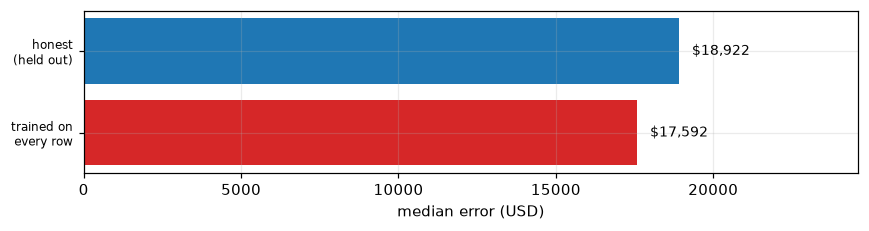

In [7]:
cheat = R.cheating_comparison(df)

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.barh(range(len(cheat)), cheat["median error"], color=["tab:blue", "tab:red"])
ax.set_yticks(range(len(cheat)))
ax.set_yticklabels(["honest\n(held out)", "trained on\nevery row"], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, cheat["median error"].max() * 1.3)
for i, v in enumerate(cheat["median error"]):
    ax.text(v + 400, i, f"${v:,.0f}", va="center", fontsize=9)
ax.set_xlabel("median error (USD)")
plt.tight_layout(); plt.show()